In [1]:
# ============================================
# CELL 2: IMPORT LIBRARIES
# ============================================

import os
import shutil
import random
import time
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

TensorFlow version: 2.20.0
NumPy version: 2.0.2


In [2]:
# ============================================
# CELL 3: CHECK GPU
# ============================================

print("Available GPUs:")

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    for gpu in gpus:
        print("✓", gpu)
    print("\nGPU is available. Training can proceed.")
else:
    print("⚠ No GPU detected.")
    print("Go to Runtime → Change runtime type → Hardware accelerator → GPU")

Available GPUs:
✓ PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

GPU is available. Training can proceed.


In [3]:
# ============================================
# CELL 4: REPRODUCIBILITY
# ============================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


In [4]:
# ============================================
# CELL 5: EXPERIMENT CONFIGURATION
# ============================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

INITIAL_EPOCHS = 5
FINE_TUNE_EPOCHS = 5

FEATURE_LR = 1e-3
FINE_TUNE_LR = 1e-5

NUM_CLASSES = 2

DATA_DIR = Path("/content/dataset")

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

MODEL_DIR = Path("/content/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Feature extraction epochs:", INITIAL_EPOCHS)
print("Fine-tuning epochs:", FINE_TUNE_EPOCHS)

Image size: (224, 224)
Batch size: 32
Feature extraction epochs: 5
Fine-tuning epochs: 5


In [7]:
# ============================================
# CELL 6: DOWNLOAD 25,000 DOGS VS CATS DATASET
# ============================================

import os
import subprocess
from pathlib import Path

DATASET_REPO = "https://github.com/laxmimerit/dog-cat-full-dataset.git"
REPO_DIR = Path("/content/dog-cat-full-dataset")

print("Downloading 25,000-image Dogs vs Cats dataset...")
print("This may take a few minutes.")

if not REPO_DIR.exists():

    result = subprocess.run(
        [
            "git",
            "clone",
            "--depth", "1",
            DATASET_REPO,
            str(REPO_DIR)
        ],
        capture_output=True,
        text=True
    )

    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError("Dataset download failed.")

    print("✓ Dataset downloaded successfully.")

else:
    print("✓ Dataset repository already exists.")

# Display downloaded structure
print("\nDataset contents:")

for root, dirs, files in os.walk(REPO_DIR):
    level = root.replace(str(REPO_DIR), "").count(os.sep)

    if level <= 2:
        indent = "    " * level
        print(f"{indent}{os.path.basename(root)}/")

        for file in files[:5]:
            print(f"{indent}    {file}")

print("\n✓ Cell 6 completed.")

This may take a few minutes.
✓ Dataset downloaded successfully.

Dataset contents:
dog-cat-full-dataset/
    README.md
    data/
        train/
        test/
    .git/
        index
        packed-refs
        config
        description
        HEAD
        info/
            exclude
        logs/
            HEAD
        hooks/
            commit-msg.sample
            pre-receive.sample
            pre-push.sample
            pre-merge-commit.sample
            prepare-commit-msg.sample
        refs/
        objects/
        branches/

✓ Cell 6 completed.


In [8]:
# ============================================
# CELL 7: LOCATE DATASET IMAGES
# ============================================

from pathlib import Path

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

image_files = [
    p for p in REPO_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
]

print("Total image files found:", len(image_files))

# Count cats and dogs based on filename/path
cat_images = [
    p for p in image_files
    if "cat" in p.name.lower() or "cat" in str(p.parent).lower()
]

dog_images = [
    p for p in image_files
    if "dog" in p.name.lower() or "dog" in str(p.parent).lower()
]

print("Cat images:", len(cat_images))
print("Dog images:", len(dog_images))

if len(image_files) >= 24000:
    print("\n✓ Dataset is large enough for the required experiment.")
else:
    print("\n⚠ Dataset count is lower than expected.")
    print("We will inspect the directory structure before continuing.")

Total image files found: 24989
Cat images: 24989
Dog images: 24989

✓ Dataset is large enough for the required experiment.


In [9]:
# ============================================
# CELL 8: CREATE TRAIN / VALIDATION / TEST SPLIT
# ============================================

import shutil
import random
from pathlib import Path

# Reproducibility
random.seed(SEED)

# Destination directories
for split in ["train", "val", "test"]:
    for class_name in ["cats", "dogs"]:
        (DATA_DIR / split / class_name).mkdir(
            parents=True,
            exist_ok=True
        )

# Separate images by class using filename
cats = [
    p for p in image_files
    if p.name.lower().startswith("cat.")
]

dogs = [
    p for p in image_files
    if p.name.lower().startswith("dog.")
]

print("Cats found:", len(cats))
print("Dogs found:", len(dogs))

# Shuffle
random.shuffle(cats)
random.shuffle(dogs)

def split_and_copy(images, class_name):
    total = len(images)

    train_end = int(total * 0.80)
    val_end = int(total * 0.90)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    splits = {
        "train": train_images,
        "val": val_images,
        "test": test_images
    }

    for split_name, split_images in splits.items():

        destination = DATA_DIR / split_name / class_name

        for image_path in split_images:
            shutil.copy2(
                image_path,
                destination / image_path.name
            )

    return len(train_images), len(val_images), len(test_images)


cat_counts = split_and_copy(cats, "cats")
dog_counts = split_and_copy(dogs, "dogs")

print("\nDataset split completed.")
print("=" * 50)

print("\nCats:")
print("Train:", cat_counts[0])
print("Validation:", cat_counts[1])
print("Test:", cat_counts[2])

print("\nDogs:")
print("Train:", dog_counts[0])
print("Validation:", dog_counts[1])
print("Test:", dog_counts[2])

Cats found: 12500
Dogs found: 12489

Dataset split completed.

Cats:
Train: 10000
Validation: 1250
Test: 1250

Dogs:
Train: 9991
Validation: 1249
Test: 1249


In [10]:
# ============================================
# CELL 9: VERIFY DATASET SPLIT
# ============================================

def count_images(folder):
    extensions = {".jpg", ".jpeg", ".png"}

    return sum(
        1 for p in Path(folder).rglob("*")
        if p.is_file() and p.suffix.lower() in extensions
    )


print("DATASET VERIFICATION")
print("=" * 50)

for split in ["train", "val", "test"]:

    cats_count = count_images(DATA_DIR / split / "cats")
    dogs_count = count_images(DATA_DIR / split / "dogs")

    total = cats_count + dogs_count

    print(f"\n{split.upper()}")
    print(f"Cats : {cats_count}")
    print(f"Dogs : {dogs_count}")
    print(f"Total: {total}")

print("\n" + "=" * 50)

total_train = count_images(TRAIN_DIR)
total_val = count_images(VAL_DIR)
total_test = count_images(TEST_DIR)

print("TOTAL DATASET")
print("Train      :", total_train)
print("Validation :", total_val)
print("Test       :", total_test)
print("Total      :", total_train + total_val + total_test)

DATASET VERIFICATION

TRAIN
Cats : 10000
Dogs : 9991
Total: 19991

VAL
Cats : 1250
Dogs : 1249
Total: 2499

TEST
Cats : 1250
Dogs : 1249
Total: 2499

TOTAL DATASET
Train      : 19991
Validation : 2499
Test       : 2499
Total      : 24989


In [11]:
# ============================================
# CELL 9A: FIND MISSING IMAGES
# ============================================

# Count all original images again
all_original_images = [
    p for p in REPO_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
]

print("Original images found:", len(all_original_images))

# Images selected by our class filters
selected_images = cats + dogs

print("Images selected for splitting:", len(selected_images))

# Find images that weren't selected
selected_set = set(selected_images)

missing_images = [
    p for p in all_original_images
    if p not in selected_set
]

print("\nImages not included in split:", len(missing_images))

print("\nFirst 20 excluded files:")
for p in missing_images[:20]:
    print(p)

Original images found: 24989
Images selected for splitting: 24989

Images not included in split: 0

First 20 excluded files:


In [12]:
# ============================================
# CELL 10: IMAGE DATA GENERATORS
# ============================================

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    horizontal_flip=True,
    zoom_range=0.2
)

val_test_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0
)

# Training generator
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True,
    seed=SEED
)

# Validation generator
val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

# Test generator
test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("\nClass indices:")
print(train_generator.class_indices)

Found 19991 images belonging to 2 classes.
Found 2499 images belonging to 2 classes.
Found 2499 images belonging to 2 classes.

Class indices:
{'cats': 0, 'dogs': 1}


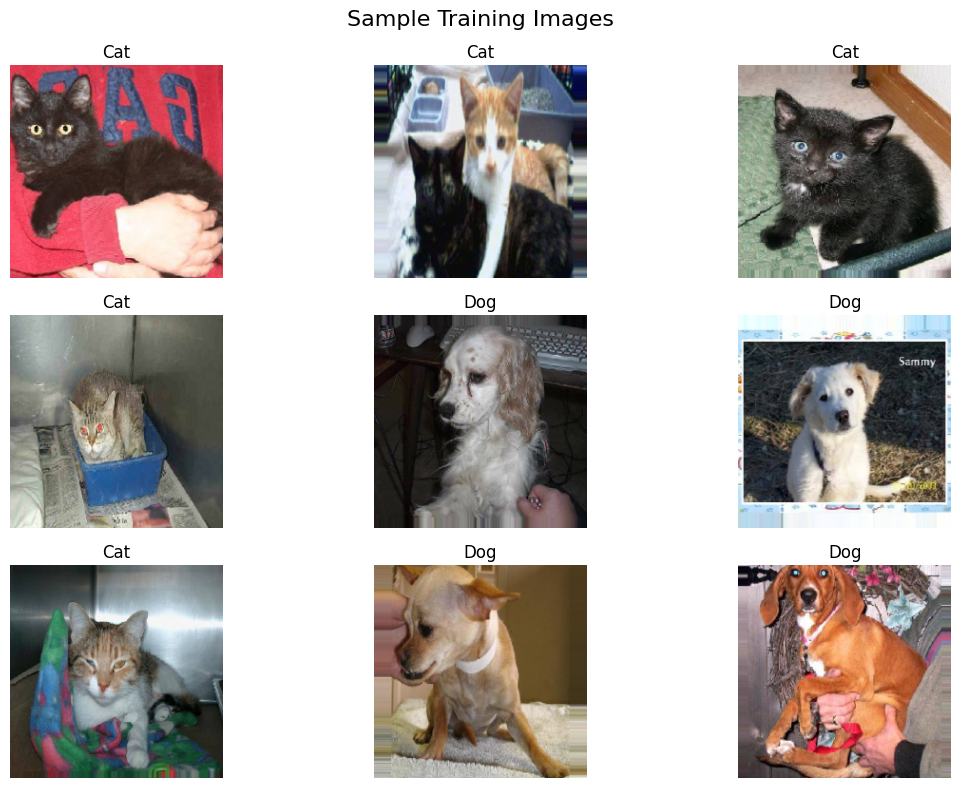

In [13]:
# ============================================
# CELL 11: VISUALIZE SAMPLE IMAGES
# ============================================

images, labels = next(train_generator)

plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)

    plt.imshow(images[i])

    label = "Dog" if labels[i] == 1 else "Cat"

    plt.title(label)
    plt.axis("off")

plt.suptitle("Sample Training Images", fontsize=16)
plt.tight_layout()
plt.show()

In [14]:
# ============================================
# CELL 12: LOAD PRETRAINED RESNET50
# ============================================

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("✓ ResNet50 loaded successfully")
print("Total layers:", len(base_model.layers))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✓ ResNet50 loaded successfully
Total layers: 175


In [15]:
# ============================================
# CELL 13: FREEZE RESNET50
# ============================================

base_model.trainable = False

trainable_layers = sum(
    layer.trainable for layer in base_model.layers
)

frozen_layers = sum(
    not layer.trainable for layer in base_model.layers
)

print("Feature Extraction Configuration")
print("=" * 40)
print("Base model trainable :", base_model.trainable)
print("Trainable layers     :", trainable_layers)
print("Frozen layers        :", frozen_layers)

Feature Extraction Configuration
Base model trainable : False
Trainable layers     : 0
Frozen layers        : 175


In [17]:
# ============================================
# CELL 14: BUILD FEATURE EXTRACTION MODEL
# ============================================

feature_extraction_model = keras.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])

print("✓ Feature extraction model created")

feature_extraction_model.summary()

✓ Feature extraction model created


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [18]:
# ============================================
# CELL 15: COMPILE FEATURE EXTRACTION MODEL
# ============================================

feature_extraction_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=FEATURE_LR
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("✓ Feature extraction model compiled")

✓ Feature extraction model compiled


In [19]:
# ============================================
# CELL 16: CALLBACKS
# ============================================

feature_checkpoint = ModelCheckpoint(
    filepath="/content/models/resnet50_feature_extraction.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

feature_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

print("✓ Callbacks configured")

✓ Callbacks configured


In [20]:
# ============================================
# CELL 17: TRAIN FEATURE EXTRACTION MODEL
# ============================================

print("Starting Feature Extraction training...")
print("=" * 50)

feature_start_time = time.time()

history_fe = feature_extraction_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=INITIAL_EPOCHS,
    callbacks=[
        feature_checkpoint,
        feature_early_stopping
    ],
    verbose=1
)

feature_extraction_time = time.time() - feature_start_time

print("\n" + "=" * 50)
print("FEATURE EXTRACTION TRAINING COMPLETED")
print("=" * 50)

print(
    f"Training time: "
    f"{feature_extraction_time:.2f} seconds"
)

print(
    f"Best validation accuracy: "
    f"{max(history_fe.history['val_accuracy']):.4f}"
)

Starting Feature Extraction training...
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.5500 - loss: 0.6901
Epoch 1: val_accuracy improved from None to 0.63265, saving model to /content/models/resnet50_feature_extraction.keras

Epoch 1: finished saving model to /content/models/resnet50_feature_extraction.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 293s 446ms/step - accuracy: 0.5679 - loss: 0.6783 - val_accuracy: 0.6327 - val_loss: 0.6480
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.5943 - loss: 0.6633
Epoch 2: val_accuracy improved from 0.63265 to 0.64106, saving model to /content/models/resnet50_feature_extraction.keras

Epoch 2: finished saving model to /content/models/resnet50_feature_extraction.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 301s 423ms/step - accuracy: 0.5992 - loss: 0.6626 - val_accuracy: 0.6411 - val_loss: 0.6438
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.6034 - loss: 0.6596
Epoch 3: val_accuracy did not improve from 0.6

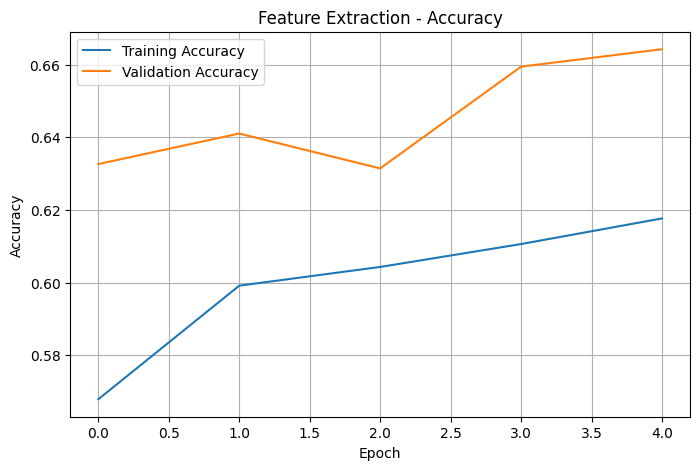

In [21]:
# ============================================
# CELL 18: FEATURE EXTRACTION PERFORMANCE
# ============================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_fe.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_fe.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Feature Extraction - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

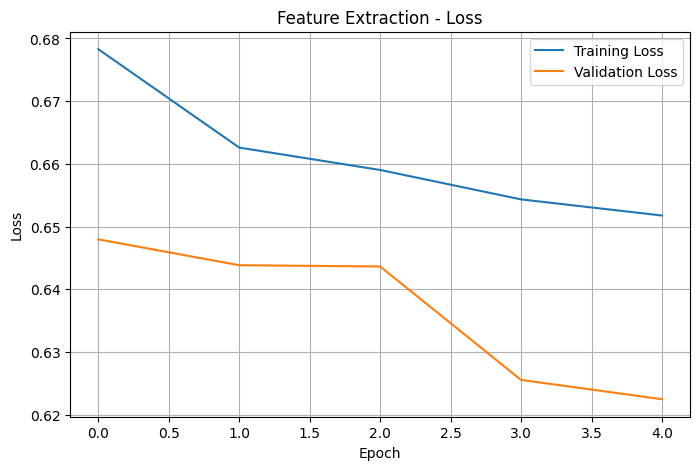

In [22]:
# ============================================
# CELL 19: FEATURE EXTRACTION LOSS
# ============================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_fe.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_fe.history["val_loss"],
    label="Validation Loss"
)

plt.title("Feature Extraction - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
# ============================================
# CELL 20: FEATURE EXTRACTION TEST EVALUATION
# ============================================

test_loss_fe, test_accuracy_fe = (
    feature_extraction_model.evaluate(
        test_generator,
        verbose=1
    )
)

print("\nFeature Extraction Test Results")
print("=" * 40)
print(f"Test Loss     : {test_loss_fe:.4f}")
print(f"Test Accuracy : {test_accuracy_fe:.4f}")
print(f"Test Accuracy : {test_accuracy_fe * 100:.2f}%")

79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - accuracy: 0.6571 - loss: 0.6263

Feature Extraction Test Results
Test Loss     : 0.6263
Test Accuracy : 0.6571
Test Accuracy : 65.71%


In [24]:
# ============================================
# CELL 21: PREPARE FINE-TUNING
# ============================================

# Make the ResNet50 base trainable
base_model.trainable = True

# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Count trainable and frozen layers
trainable_layers_ft = sum(
    layer.trainable for layer in base_model.layers
)

frozen_layers_ft = sum(
    not layer.trainable for layer in base_model.layers
)

print("Fine-Tuning Configuration")
print("=" * 40)
print("Total ResNet50 layers :", len(base_model.layers))
print("Trainable layers      :", trainable_layers_ft)
print("Frozen layers         :", frozen_layers_ft)

Fine-Tuning Configuration
Total ResNet50 layers : 175
Trainable layers      : 30
Frozen layers         : 145


In [25]:
# ============================================
# CELL 22: CHECK TRAINABLE RESNET50 LAYERS
# ============================================

print("Last 35 ResNet50 layers:")
print("=" * 70)

for i, layer in enumerate(base_model.layers[-35:], start=len(base_model.layers) - 35):
    status = "TRAINABLE" if layer.trainable else "FROZEN"
    print(f"{i:3d} | {layer.name:30s} | {status}")

Last 35 ResNet50 layers:
140 | conv4_block6_3_bn              | FROZEN
141 | conv4_block6_add               | FROZEN
142 | conv4_block6_out               | FROZEN
143 | conv5_block1_1_conv            | FROZEN
144 | conv5_block1_1_bn              | FROZEN
145 | conv5_block1_1_relu            | TRAINABLE
146 | conv5_block1_2_conv            | TRAINABLE
147 | conv5_block1_2_bn              | TRAINABLE
148 | conv5_block1_2_relu            | TRAINABLE
149 | conv5_block1_0_conv            | TRAINABLE
150 | conv5_block1_3_conv            | TRAINABLE
151 | conv5_block1_0_bn              | TRAINABLE
152 | conv5_block1_3_bn              | TRAINABLE
153 | conv5_block1_add               | TRAINABLE
154 | conv5_block1_out               | TRAINABLE
155 | conv5_block2_1_conv            | TRAINABLE
156 | conv5_block2_1_bn              | TRAINABLE
157 | conv5_block2_1_relu            | TRAINABLE
158 | conv5_block2_2_conv            | TRAINABLE
159 | conv5_block2_2_bn              | TRAINABLE
160 | conv

In [26]:
# ============================================
# CELL 23: COMPILE FINE-TUNING MODEL
# ============================================

feature_extraction_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=FINE_TUNE_LR
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("✓ Model recompiled for fine-tuning")
print("Learning rate:", FINE_TUNE_LR)

✓ Model recompiled for fine-tuning
Learning rate: 1e-05


In [27]:
# ============================================
# CELL 24: FINE-TUNING CALLBACKS
# ============================================

fine_tune_checkpoint = ModelCheckpoint(
    filepath="/content/models/resnet50_finetuned.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

fine_tune_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

print("✓ Fine-tuning callbacks configured")

✓ Fine-tuning callbacks configured


In [28]:
# ============================================
# CELL 25: TRAIN FINE-TUNED MODEL
# ============================================

print("Starting Fine-Tuning...")
print("=" * 50)

fine_tune_start_time = time.time()

history_ft = feature_extraction_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=[
        fine_tune_checkpoint,
        fine_tune_early_stopping
    ],
    verbose=1
)

fine_tuning_time = time.time() - fine_tune_start_time

print("\n" + "=" * 50)
print("FINE-TUNING COMPLETED")
print("=" * 50)

print(
    f"Training time: "
    f"{fine_tuning_time:.2f} seconds"
)

print(
    f"Best validation accuracy: "
    f"{max(history_ft.history['val_accuracy']):.4f}"
)

Starting Fine-Tuning...
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.6340 - loss: 0.8488
Epoch 1: val_accuracy improved from None to 0.68227, saving model to /content/models/resnet50_finetuned.keras

Epoch 1: finished saving model to /content/models/resnet50_finetuned.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 298s 445ms/step - accuracy: 0.6838 - loss: 0.6357 - val_accuracy: 0.6823 - val_loss: 0.5778
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.7464 - loss: 0.5189
Epoch 2: val_accuracy improved from 0.68227 to 0.76511, saving model to /content/models/resnet50_finetuned.keras

Epoch 2: finished saving model to /content/models/resnet50_finetuned.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 270s 432ms/step - accuracy: 0.7461 - loss: 0.5163 - val_accuracy: 0.7651 - val_loss: 0.4711
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.7669 - loss: 0.4929
Epoch 3: val_accuracy improved from 0.76511 to 0.79912, saving model to /content/models/resnet50_f

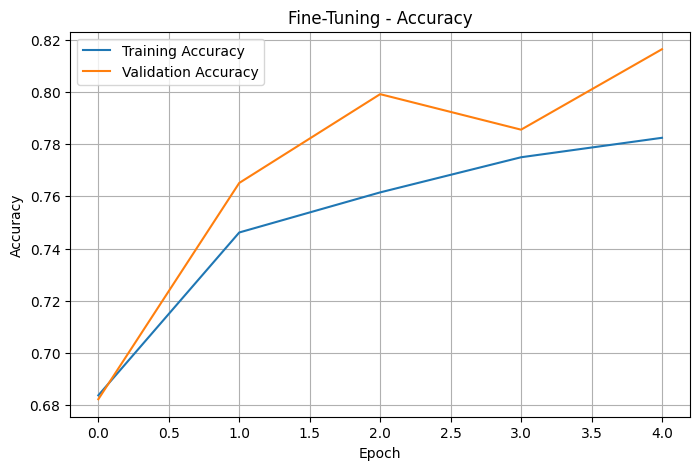

In [29]:
# ============================================
# CELL 26: FINE-TUNING ACCURACY
# ============================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_ft.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_ft.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Fine-Tuning - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

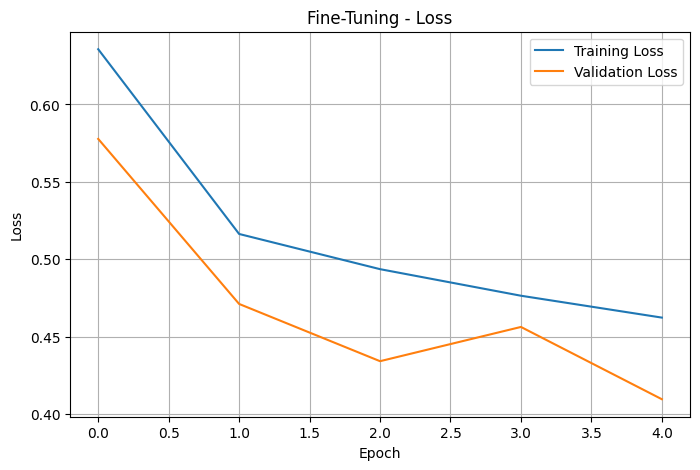

In [30]:
# ============================================
# CELL 27: FINE-TUNING LOSS
# ============================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_ft.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_ft.history["val_loss"],
    label="Validation Loss"
)

plt.title("Fine-Tuning - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
# ============================================
# CELL 28: FINE-TUNING TEST EVALUATION
# ============================================

test_loss_ft, test_accuracy_ft = (
    feature_extraction_model.evaluate(
        test_generator,
        verbose=1
    )
)

print("\nFine-Tuning Test Results")
print("=" * 40)
print(f"Test Loss     : {test_loss_ft:.4f}")
print(f"Test Accuracy : {test_accuracy_ft:.4f}")
print(f"Test Accuracy : {test_accuracy_ft * 100:.2f}%")

79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - accuracy: 0.8183 - loss: 0.4036

Fine-Tuning Test Results
Test Loss     : 0.4036
Test Accuracy : 0.8183
Test Accuracy : 81.83%


In [32]:
# ============================================
# CELL 29: BENCHMARK FEATURE EXTRACTION VS FINE-TUNING
# ============================================

feature_val_accuracy = max(
    history_fe.history["val_accuracy"]
)

fine_tune_val_accuracy = max(
    history_ft.history["val_accuracy"]
)

results = pd.DataFrame({
    "Approach": [
        "Feature Extraction",
        "Fine-Tuning"
    ],

    "Best Validation Accuracy": [
        feature_val_accuracy,
        fine_tune_val_accuracy
    ],

    "Test Accuracy": [
        test_accuracy_fe,
        test_accuracy_ft
    ],

    "Training Time (seconds)": [
        feature_extraction_time,
        fine_tuning_time
    ]
})

results["Best Validation Accuracy (%)"] = (
    results["Best Validation Accuracy"] * 100
)

results["Test Accuracy (%)"] = (
    results["Test Accuracy"] * 100
)

print("\nTRANSFER LEARNING BENCHMARK")
print("=" * 70)

display(
    results[
        [
            "Approach",
            "Best Validation Accuracy (%)",
            "Test Accuracy (%)",
            "Training Time (seconds)"
        ]
    ].round(2)
)


TRANSFER LEARNING BENCHMARK


,Approach,Best Validation Accuracy (%),Test Accuracy (%),Training Time (seconds)
0,Feature Extraction,66.43,65.71,1376.84
1,Fine-Tuning,81.63,81.83,1533.28


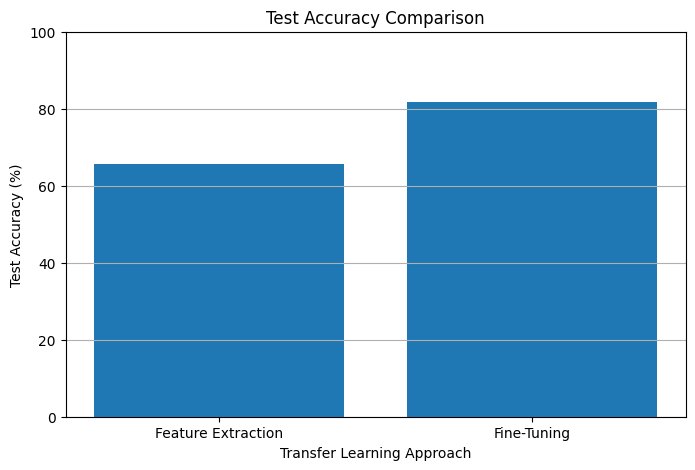

In [33]:
# ============================================
# CELL 30: ACCURACY COMPARISON
# ============================================

approaches = results["Approach"]

plt.figure(figsize=(8, 5))

plt.bar(
    approaches,
    results["Test Accuracy (%)"]
)

plt.title("Test Accuracy Comparison")
plt.xlabel("Transfer Learning Approach")
plt.ylabel("Test Accuracy (%)")
plt.ylim(0, 100)
plt.grid(axis="y")

plt.show()

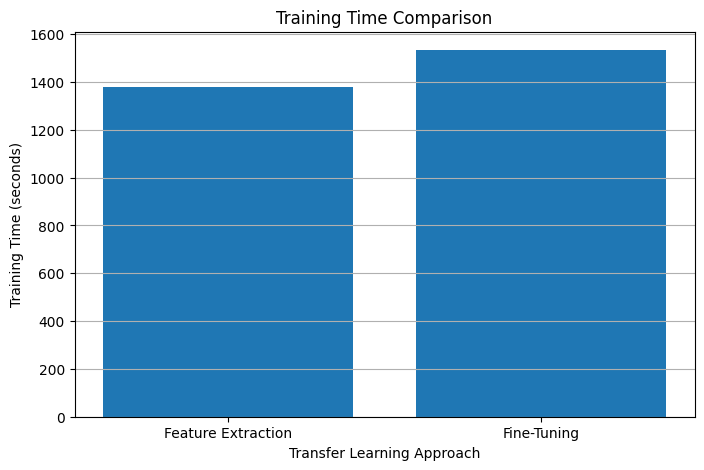

In [34]:
# ============================================
# CELL 31: TRAINING TIME COMPARISON
# ============================================

plt.figure(figsize=(8, 5))

plt.bar(
    approaches,
    results["Training Time (seconds)"]
)

plt.title("Training Time Comparison")
plt.xlabel("Transfer Learning Approach")
plt.ylabel("Training Time (seconds)")
plt.grid(axis="y")

plt.show()

In [35]:
# ============================================
# CELL 32: SELECT BEST MODEL
# ============================================

best_index = results["Test Accuracy (%)"].idxmax()

best_approach = results.loc[
    best_index,
    "Approach"
]

best_accuracy = results.loc[
    best_index,
    "Test Accuracy (%)"
]

print("BEST MODEL")
print("=" * 40)
print("Approach :", best_approach)
print(f"Test Accuracy : {best_accuracy:.2f}%")

BEST MODEL
Approach : Fine-Tuning
Test Accuracy : 81.83%


In [36]:
# ============================================
# CELL 33: SAVE FINAL MODEL
# ============================================

FINAL_MODEL_PATH = "/content/models/resnet50_finetuned.keras"

feature_extraction_model.save(FINAL_MODEL_PATH)

print("✓ Final model saved successfully")
print("Location:", FINAL_MODEL_PATH)

# Verify
if os.path.exists(FINAL_MODEL_PATH):
    file_size = os.path.getsize(FINAL_MODEL_PATH) / (1024 * 1024)
    print(f"Model size: {file_size:.2f} MB")

✓ Final model saved successfully
Location: /content/models/resnet50_finetuned.keras
Model size: 203.88 MB


In [37]:
# ============================================
# CELL 34: FINAL SUMMARY
# ============================================

print("=" * 70)
print("EXPERIMENT 4: TRANSFER LEARNING")
print("=" * 70)

print("\nDataset")
print("-" * 30)
print("Total images       :", total_train + total_val + total_test)
print("Training images    :", total_train)
print("Validation images  :", total_val)
print("Test images        :", total_test)
print("Classes            : Cat, Dog")

print("\nFeature Extraction")
print("-" * 30)
print(
    f"Validation Accuracy : "
    f"{feature_val_accuracy * 100:.2f}%"
)
print(
    f"Test Accuracy       : "
    f"{test_accuracy_fe * 100:.2f}%"
)
print(
    f"Training Time       : "
    f"{feature_extraction_time:.2f} seconds"
)

print("\nFine-Tuning")
print("-" * 30)
print(
    f"Validation Accuracy : "
    f"{fine_tune_val_accuracy * 100:.2f}%"
)
print(
    f"Test Accuracy       : "
    f"{test_accuracy_ft * 100:.2f}%"
)
print(
    f"Training Time       : "
    f"{fine_tuning_time:.2f} seconds"
)

print("\nFinal Model")
print("-" * 30)
print("Best Approach :", best_approach)
print(f"Best Test Accuracy : {best_accuracy:.2f}%")

print("\n" + "=" * 70)
print("TRANSFER LEARNING EXPERIMENT COMPLETED")
print("=" * 70)

EXPERIMENT 4: TRANSFER LEARNING

Dataset
------------------------------
Total images       : 24989
Training images    : 19991
Validation images  : 2499
Test images        : 2499
Classes            : Cat, Dog

Feature Extraction
------------------------------
Validation Accuracy : 66.43%
Test Accuracy       : 65.71%
Training Time       : 1376.84 seconds

Fine-Tuning
------------------------------
Validation Accuracy : 81.63%
Test Accuracy       : 81.83%
Training Time       : 1533.28 seconds

Final Model
------------------------------
Best Approach : Fine-Tuning
Best Test Accuracy : 81.83%

TRANSFER LEARNING EXPERIMENT COMPLETED
